# 07 - Render a real scene

Every scene rendered so far was placed by hand: a sphere whose disks we
aimed ourselves. The method exists to render photographed reality. A scene
trained by the official 3DGS pipeline arrives as a single `.ply`, and its
contents are exactly our representation: means, wxyz quaternions,
log-scales, opacity logits, and 48 spherical harmonic numbers per splat.
Notebooks 03 through 06 chose each of those pieces to match, on purpose.
What remains is packaging: parse the file, undo its activations, assemble
the SH layout, and pay the CPU bill honestly.

Nothing in this repo downloads data. `data/README.md` says where to get a
trained scene (the official Inria pretrained models, or any 3DGS training
output) and where to put it: `data/<scene>/point_cloud.ply`. When no scene
is present, this notebook builds a synthetic stand-in in the same format,
renders that instead, and says so. Every assert runs either way.

In [1]:
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from plyfile import PlyData, PlyElement
from gsplat_edu import Camera, render_gaussians, sphere_shell, eval_sh, C1

ROOT = pathlib.Path(".").resolve()
OUT = ROOT / "out"; OUT.mkdir(exist_ok=True)
DATA = ROOT / "data"

## The layout

One `vertex` element, 62 float32 properties per splat, in this exact
order:

```
x y z                     mean, world coords
nx ny nz                  normals, always zero, unused
f_dc_0..2                 SH degree-0 coefficients, one per channel
f_rest_0..44              SH degrees 1-3, flattened channel-major
opacity                   pre-activation logit
scale_0..2                pre-activation log-scales
rot_0..3                  quaternion, wxyz order
```

The order is binding because the file offers no schema beyond property
names. Before trusting a quarter-gigabyte binary, pin the layout on a
file where every number is chosen by hand: write a four-splat ply, read
it back, and require every field bit-exact.

In [2]:
FIELDS = (["x", "y", "z", "nx", "ny", "nz"]
          + [f"f_dc_{i}" for i in range(3)]
          + [f"f_rest_{i}" for i in range(45)]
          + ["opacity"]
          + [f"scale_{i}" for i in range(3)]
          + [f"rot_{i}" for i in range(4)])

def write_gs_ply(path, means, f_dc, f_rest, opacity_raw, scale_raw, rot):
    """Write file-domain (pre-activation) arrays in the trained-ply layout."""
    n = len(means)
    cols = np.hstack([means, np.zeros((n, 3)), f_dc, f_rest,
                      opacity_raw[:, None], scale_raw, rot]).astype(np.float32)
    assert cols.shape == (n, 62)
    vert = np.rec.fromarrays(cols.T, dtype=[(f, "f4") for f in FIELDS])
    PlyData([PlyElement.describe(vert, "vertex")]).write(str(path))

rng = np.random.default_rng(7)
tiny = [rng.normal(size=s) for s in
        [(4, 3), (4, 3), (4, 45), (4,), (4, 3), (4, 4)]]
write_gs_ply(OUT / "roundtrip.ply", *tiny)

v = PlyData.read(str(OUT / "roundtrip.ply"))["vertex"]
assert [p.name for p in v.properties] == FIELDS
back = np.stack([np.asarray(v[f]) for f in FIELDS], axis=1)
written = np.hstack([tiny[0], np.zeros((4, 3)), tiny[1], tiny[2],
                     tiny[3][:, None], tiny[4], tiny[5]]).astype(np.float32)
assert np.array_equal(back, written)
print("round-trip: 62 properties, order pinned, values bit-exact")

round-trip: 62 properties, order pinned, values bit-exact


## Assembling the spherical harmonics

`f_dc` holds the three degree-0 coefficients. The other 45 were flattened
from an array of shape `(3, 15)`, channel outermost: `f_rest_j` is channel
`j // 15`, band coefficient `j % 15`. Notebook 06's `eval_sh` wants
`(N, 16, 3)`, so: reshape to `(N, 3, 15)`, transpose the last two axes,
and concatenate the dc block in front. Getting this wrong does not crash;
it quietly scrambles 45 of the 48 numbers, so the mapping gets its own
assert on values chosen to expose it.

In [3]:
def assemble_sh(f_dc, f_rest):
    """(N, 3) dc and (N, 45) flattened rest -> (N, 16, 3)."""
    n = len(f_dc)
    rest = f_rest.reshape(n, 3, 15).transpose(0, 2, 1)
    return np.concatenate([f_dc[:, None, :], rest], axis=1)

probe = np.arange(45, dtype=float)[None, :]        # f_rest_j stores j
sh_probe = assemble_sh(np.full((1, 3), -1.0), probe)
for c in range(3):
    for k in range(15):
        assert sh_probe[0, 1 + k, c] == c * 15 + k
assert np.all(sh_probe[0, 0] == -1.0)
print("sh assembly: channel-major flattening inverted correctly")

sh assembly: channel-major flattening inverted correctly


## Exercise

The file stores raw values; the renderer needs activated ones. Per
`docs/DECISIONS.md`: `opacity = sigmoid(raw)` and `scale = exp(raw)`.
The stand-in scene below must ship opacity 0.8 and scales
`(0.02, 0.02, 0.004)`. Derive the raw numbers the file has to contain,
as expressions, and state why training stores these fields raw instead
of storing the activated values. Work it before scrolling.

## Solution

Invert each activation. `sigmoid(t) = 1 / (1 + e^-t)` solves to
`t = log(p / (1 - p))`, the logit; `exp` inverts to `log`:

```
opacity 0.8          ->  raw = log(0.8 / 0.2) ~ 1.3863
scale 0.02, 0.004    ->  raw = log(0.02) ~ -3.912,  log(0.004) ~ -5.521
```

Training stores raw values because gradient descent updates them without
constraints: any real number maps to a valid opacity in (0, 1) and a
positive scale. The file keeps whatever the optimizer last held, so the
loader owns the activations forever.

In [4]:
def inverse_sigmoid(p):
    return np.log(p / (1.0 - p))

def sigmoid(t):
    return 1.0 / (1.0 + np.exp(-t))

assert np.allclose(sigmoid(inverse_sigmoid(0.8)), 0.8)
assert np.allclose(np.exp(np.log(0.02)), 0.02)
assert abs(inverse_sigmoid(0.8) - 1.3863) < 1e-4
print("activations invert cleanly")

activations invert cleanly


## Batched parameter conversion

Notebook 03's `quat_to_R` and `build_cov3d` take one splat at a time. A
real scene is a few hundred thousand, so both get batched: the quaternion
formula written over rows, and the covariance as an einsum over stacked
`M = R S`. Same math, checked against the scalar versions on random
inputs.

In [5]:
from gsplat_edu import quat_to_R, build_cov3d

def quat_to_R_batch(q):
    """quat_to_R over rows. q (N, 4) wxyz -> (N, 3, 3). Promoted from
    notebook 07; loading a real scene converts every splat at once."""
    q = np.asarray(q, float)
    q = q / np.linalg.norm(q, axis=-1, keepdims=True)
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    R = np.empty(q.shape[:-1] + (3, 3))
    R[..., 0, 0] = 1 - 2 * (y * y + z * z)
    R[..., 0, 1] = 2 * (x * y - w * z)
    R[..., 0, 2] = 2 * (x * z + w * y)
    R[..., 1, 0] = 2 * (x * y + w * z)
    R[..., 1, 1] = 1 - 2 * (x * x + z * z)
    R[..., 1, 2] = 2 * (y * z - w * x)
    R[..., 2, 0] = 2 * (x * z - w * y)
    R[..., 2, 1] = 2 * (y * z + w * x)
    R[..., 2, 2] = 1 - 2 * (x * x + y * y)
    return R

def build_cov3d_batch(scales, Rs):
    """build_cov3d over rows. scales (N, 3), Rs (N, 3, 3) -> (N, 3, 3)."""
    M = np.asarray(Rs, float) * np.asarray(scales, float)[..., None, :]
    return np.einsum("...ij,...kj->...ik", M, M)

q_test = rng.normal(size=(200, 4))
s_test = np.exp(rng.normal(size=(200, 3)))
R_test = quat_to_R_batch(q_test)
for i in range(0, 200, 17):
    assert np.allclose(R_test[i], quat_to_R(q_test[i]), rtol=1e-12, atol=1e-14)
    assert np.allclose(build_cov3d_batch(s_test, R_test)[i],
                       build_cov3d(s_test[i], R_test[i]),
                       rtol=1e-12, atol=1e-14)
print("batched conversions match the scalar versions")

batched conversions match the scalar versions


## A stand-in scene, in the real format

The fallback for a machine with no captures: notebook 05's sphere shell,
dressed as a trained ply. That takes one genuinely new piece: the shell
builder emits covariances directly, and the file wants quaternions plus
scales. Each disk needs any rotation whose third column is its normal
`nrm`; the axis-angle rotation carrying `e_z = (0, 0, 1)` onto `nrm` does,
with quaternion

$$\text{axis} = \frac{e_z \times n}{\lVert e_z \times n \rVert},
\qquad \theta = \arccos(n_z)$$

$$q = \left(\cos\tfrac{\theta}{2},\;
\sin\tfrac{\theta}{2} \, \text{axis}\right)$$

The two tangent columns land wherever the axis-angle map puts them, and
for a disk that freedom is free: both tangential scales are equal, so
$\Sigma = R \, \mathrm{diag}(s^2) \, R^{T}$ is invariant to spinning the
tangent frame. The
assert below closes the loop: quaternions and scales through the batched
loader path must reproduce the covariances notebook 05 built from an
explicit basis.

In [6]:
def quat_from_z_to(nrm, eps=1e-8):
    """Unit quats (N, 4) wxyz rotating e_z onto each unit normal."""
    nrm = np.asarray(nrm, float)
    axis = np.cross(np.broadcast_to([0.0, 0.0, 1.0], nrm.shape), nrm)
    s = np.linalg.norm(axis, axis=-1, keepdims=True)
    axis = np.where(s > eps, axis / np.maximum(s, eps), [1.0, 0.0, 0.0])
    half = 0.5 * np.arccos(np.clip(nrm[..., 2], -1.0, 1.0))
    return np.concatenate([np.cos(half)[..., None],
                           np.sin(half)[..., None] * axis], axis=-1)

N_STAND_IN = 30_000
P, covs_ref, base_colors, _ = sphere_shell(N_STAND_IN, s_t=0.02, s_n=0.004)
quats = quat_from_z_to(P)                      # normals point along P
Rs = quat_to_R_batch(quats)
assert np.allclose(Rs[:, :, 2], P, atol=1e-12)

scales = np.tile([0.02, 0.02, 0.004], (N_STAND_IN, 1))
assert np.allclose(build_cov3d_batch(scales, Rs), covs_ref, atol=1e-12)
print("quats + scales rebuild notebook 05's covariances exactly")

quats + scales rebuild notebook 05's covariances exactly


File-domain values, using the exercise: logit the opacity, log the
scales, and encode color in SH. Degree 0 carries each disk's base color;
one degree-1 coefficient adds a hand-authored view tint (redder from +x,
bluer from -x, notebook 06's exercise splat), so the stand-in exercises
all 48 numbers end to end.

In [7]:
f_dc = (base_colors - 0.5) / 0.28209479177387814
f_rest = np.zeros((N_STAND_IN, 45))
f_rest[:, 0 * 15 + 2] = -0.20 / C1      # sh[3] red,  channel-major col 2
f_rest[:, 2 * 15 + 2] = +0.20 / C1      # sh[3] blue, channel-major col 32

stand_in = DATA / "_synthetic"; stand_in.mkdir(exist_ok=True)
write_gs_ply(stand_in / "point_cloud.ply", P, f_dc, f_rest,
             np.full(N_STAND_IN, inverse_sigmoid(0.8)),
             np.log(scales), quats)
print("wrote", (stand_in / "point_cloud.ply").relative_to(ROOT),
      f"({(stand_in / 'point_cloud.ply').stat().st_size / 1e6:.1f} MB)")

wrote data/_synthetic/point_cloud.ply (7.4 MB)


## Pick a scene and load it

Any `data/<scene>/point_cloud.ply` that is not the stand-in wins;
otherwise the stand-in stands in.

In [8]:
def load_gs_ply(path):
    """Trained ply -> activated arrays.

    Returns means (N,3), sh (N,16,3), opacities (N,), scales (N,3),
    quats (N,4) wxyz, all float64. Activations per docs/DECISIONS.md;
    quats returned raw (quat_to_R_batch normalizes).
    """
    v = PlyData.read(str(path))["vertex"]
    col = lambda names: np.stack([np.asarray(v[n], float) for n in names], 1)
    means = col(["x", "y", "z"])
    sh = assemble_sh(col([f"f_dc_{i}" for i in range(3)]),
                     col([f"f_rest_{i}" for i in range(45)]))
    opacities = sigmoid(np.asarray(v["opacity"], float))
    scales = np.exp(col([f"scale_{i}" for i in range(3)]))
    quats = col([f"rot_{i}" for i in range(4)])
    return means, sh, opacities, scales, quats

real = sorted(p for p in DATA.glob("*/point_cloud.ply")
              if p.parent.name != "_synthetic")
if real:
    scene_path, scene_name = real[0], real[0].parent.name
    print(f"real scene found: {scene_name}")
else:
    scene_path, scene_name = stand_in / "point_cloud.ply", "_synthetic"
    print("no real scene under data/<scene>/point_cloud.ply -")
    print("rendering the synthetic stand-in; see data/README.md for sources")

means, sh, opacities, scales_a, quats = load_gs_ply(scene_path)
print(f"{scene_name}: {len(means):,} splats loaded")

qn = np.linalg.norm(quats, axis=-1)
assert np.all(np.isfinite(qn)) and np.all(qn > 0.1), "degenerate quaternions"
assert np.all((opacities > 0) & (opacities < 1))
assert np.all(scales_a > 0)
assert sh.shape == (len(means), 16, 3)
print("activated: opacities in (0, 1), scales positive, quats clean")

no real scene under data/<scene>/point_cloud.ply -
rendering the synthetic stand-in; see data/README.md for sources
_synthetic: 30,000 splats loaded
activated: opacities in (0, 1), scales positive, quats clean


The file stores raw values, and raw values make no sense fed straight to
the renderer. The left histograms say so: "scales" at -4 world units,
"opacities" spread over logits. The activations put every parameter in
its legal range. This is the break-and-fix of this notebook in one
figure; the rest is bookkeeping.

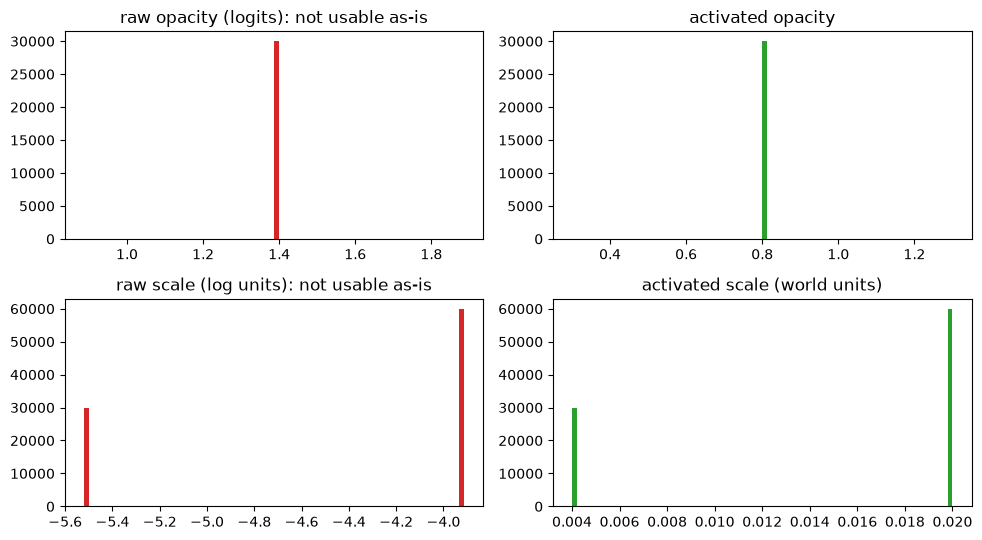

In [9]:
raw_v = PlyData.read(str(scene_path))["vertex"]
raw_op = np.asarray(raw_v["opacity"], float)
raw_sc = np.stack([np.asarray(raw_v[f"scale_{i}"], float)
                   for i in range(3)], 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 5.5))
for row, (raw, act, rname, aname) in enumerate(
        [(raw_op, opacities, "raw opacity (logits)", "activated opacity"),
         (raw_sc.ravel(), scales_a.ravel(), "raw scale (log units)",
          "activated scale (world units)")]):
    axes[row, 0].hist(raw, bins=80, color="tab:red")
    axes[row, 0].set_title(f"{rname}: not usable as-is")
    axes[row, 1].hist(act, bins=80, color="tab:green")
    axes[row, 1].set_title(aname)
plt.tight_layout()
plt.show()

## The CPU budget

A real capture holds hundreds of thousands to millions of splats, and
notebook 05 measured our renderer in single-digit millions of pixel-splat
pairs per second. Rendering all of them at full resolution is an
overnight job. The honest budget for a picture today: random-subsample
to at most 40k splats, render around 400 px. Subsampling thins the scene
(fewer splats than the training run assumed means more background leaks
through), and that is the accepted price of a pure-numpy afternoon.

In [10]:
MAX_SPLATS = 40_000
keep = (np.arange(len(means)) if len(means) <= MAX_SPLATS else
        np.sort(rng.choice(len(means), MAX_SPLATS, replace=False)))
m_s, sh_s, op_s = means[keep], sh[keep], opacities[keep]
cov_s = build_cov3d_batch(scales_a[keep], quat_to_R_batch(quats[keep]))
print(f"rendering {len(keep):,} of {len(means):,} splats")

rendering 30,000 of 30,000 splats


## A camera it chooses itself

Hand-placing cameras stops scaling the moment the scene is not ours. Two
statistics frame anything: the scene center (mean of means) and a radius
(90th percentile of distances from it, so stray far-away splats cannot
inflate the frame). Orbit at 1.5x that radius, look at the center. The
focal length follows from the same numbers: a ball of that radius seen
from 1.5x away subtends `asin(1/1.5) ~ 41.8` degrees of half-angle, so
`fx = 0.47 * size` (half-FOV ~46.8 degrees) frames it with a small
margin, whatever the scene's absolute size.

center [-0.004 -0.004  0.001], radius 1.005


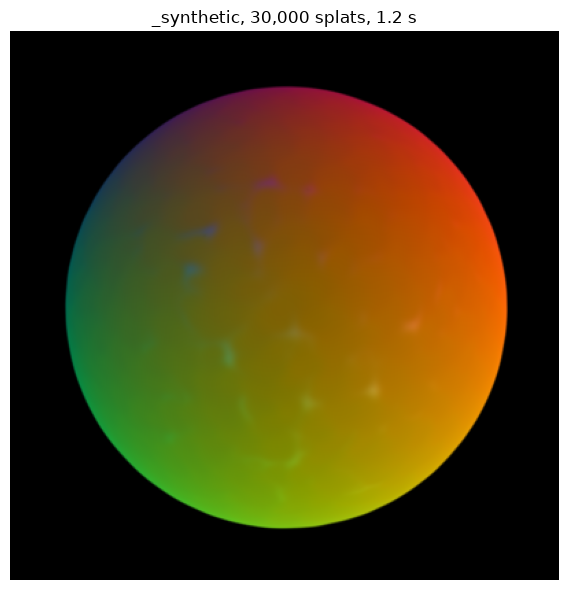

one 400 px frame: 1.2 s -> saved out/_synthetic_frame.png
at 60 fps this frame overspends its budget 70x


In [11]:
center = m_s.mean(axis=0)
radius = np.quantile(np.linalg.norm(m_s - center, axis=-1), 0.90)
orbit_r = 1.5 * radius
print(f"center {np.round(center, 3)}, radius {radius:.3f}")

def orbit_cam(az_deg, size=400, elev=-0.25):
    a = np.radians(az_deg)
    eye = center + orbit_r * np.array([np.sin(a), elev, -np.cos(a)])
    return Camera.looking_at(eye=eye, target=center,
                             fx=0.47 * size, fy=0.47 * size,
                             H=size, W=size)

def render_view(cam, deg=3):
    d = m_s - cam.eye
    d /= np.linalg.norm(d, axis=-1, keepdims=True)
    return render_gaussians(cam, m_s, cov_s, eval_sh(deg, sh_s, d), op_s)

cam0 = orbit_cam(0)
t0 = time.perf_counter()
img0, _ = render_view(cam0)
dt = time.perf_counter() - t0

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(img0, 0, 1)); plt.axis("off")
plt.title(f"{scene_name}, {len(keep):,} splats, {dt:.1f} s")
plt.tight_layout(); plt.show()

plt.imsave(OUT / f"{scene_name}_frame.png", np.clip(img0, 0, 1))
print(f"one 400 px frame: {dt:.1f} s -> saved out/{scene_name}_frame.png")
print(f"at 60 fps this frame overspends its budget {dt * 60:.0f}x")

That figure is the point of the whole phase: a scene decoded from the
trained-ply format and drawn by the renderer built in notebooks 01-05
with notebook 06's color. The printed overspend factor is the other
point, and it flatters us: it measures a scene thinned to 40k splats at
a quarter of viewer resolution. Undo both concessions on a real capture
(25x the splats, 10x the pixels) and the gap to 16 ms per frame runs to
four or five orders of magnitude. Phase D exists because of this exact
arithmetic.

## The orbit

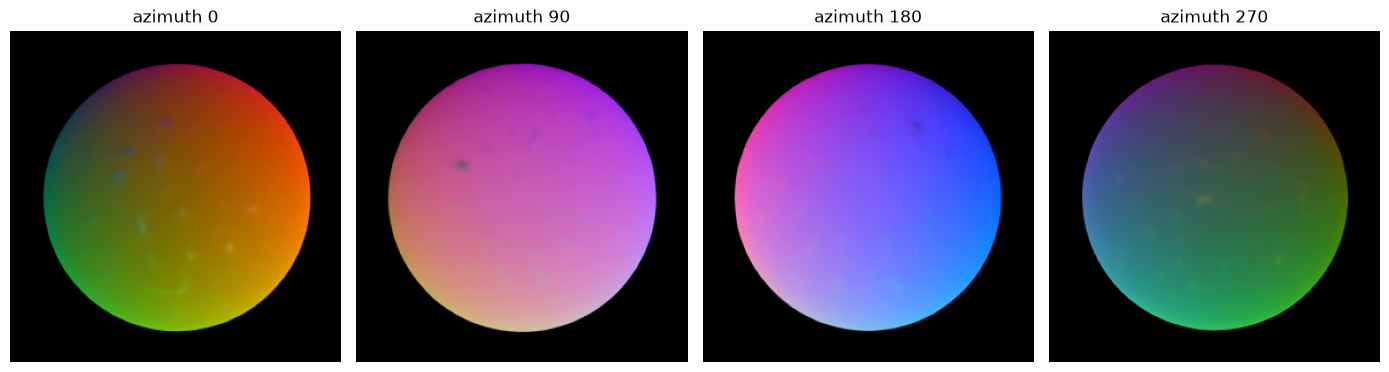

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, az in zip(axes, [0, 90, 180, 270]):
    img, _ = render_view(orbit_cam(az, size=288))
    ax.imshow(np.clip(img, 0, 1)); ax.axis("off")
    ax.set_title(f"azimuth {az}")
plt.tight_layout()
plt.show()

On the stand-in, the degree-1 tint authored into `f_rest` shows up as the
warm cast at azimuth 90 and the cool one at 270; on a real capture, this
orbit is where baked-in highlights slide across surfaces. Either way the
view dependence rides in the same 45 numbers this notebook unpacked.

## Promotion

`quat_to_R_batch` and `build_cov3d_batch` move to `gsplat_edu.gaussians`
next to their scalar parents. The ply loader stays here: it is thirty
lines of numpy against a layout this notebook already pinned, and phase C
does not need it. Prove the package matches:

In [13]:
import gsplat_edu

assert np.array_equal(quat_to_R_batch(q_test),
                      gsplat_edu.quat_to_R_batch(q_test))
assert np.array_equal(build_cov3d_batch(s_test, R_test),
                      gsplat_edu.build_cov3d_batch(s_test, R_test))
print("package batch conversions match the notebook, bit for bit")

package batch conversions match the notebook, bit for bit


## The next live problem

Phase B is closed: real captures load and render. Every splat in them,
though, was chosen by someone else's optimizer; this project still cannot
make its own. Nothing here chooses the Gaussians. Phase C starts that
from the flattest ground available: notebook 08 strips the problem to 2D,
fits a few hundred Gaussians to a single image, and derives every
gradient of the over operator by hand, because the recurrence it uncovers
is the exact structure the CUDA backward pass reuses in notebook 12.